In [60]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [61]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

def find_project_root():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data").is_dir():
            return cand
    raise FileNotFoundError(f"Folder data not found")

ROOT = find_project_root()

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ADJ_PKL_PATH = RAW_DIR / "adj_METR-LA.pkl"
SPEED_H5_PATH = RAW_DIR / "METR-LA.h5"

# Adjacency matrix

In [62]:
with open(ADJ_PKL_PATH, "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding="latin1")

adj_mx = np.asarray(adj_mx, dtype=np.float32)
num_nodes = len(sensor_ids)

print("Jumlah sensor (node):", num_nodes)
print("Shape adjacency     :", adj_mx.shape)
print("Range bobot         :", adj_mx.min(), "-", adj_mx.max())
print("Jumlah edge non-zero (termasuk self-loop):", int((adj_mx > 0).sum()))
print("Rata-rata tetangga per sensor (tanpa self-loop):", round(((adj_mx > 0).sum() - num_nodes) / num_nodes, 2))
print("\n5 sensor pertama:", sensor_ids[:5])

Jumlah sensor (node): 207
Shape adjacency     : (207, 207)
Range bobot         : 0.0 - 1.0
Jumlah edge non-zero (termasuk self-loop): 1722
Rata-rata tetangga per sensor (tanpa self-loop): 7.32

5 sensor pertama: ['773869', '767541', '767542', '717447', '717446']


In [63]:
pd.DataFrame(adj_mx, index=sensor_ids, columns=sensor_ids).iloc[:8, :8].round(3)

,773869,767541,767542,717447,717446,717445,773062,767620
773869,1.0,0.000,0.000,0.000,0.000,0.0,0.000,0.00
767541,0.0,1.000,0.391,0.000,0.000,0.0,0.000,0.39
767542,0.0,0.717,1.000,0.000,0.000,0.0,0.000,0.00
717447,0.0,0.000,0.000,1.000,0.634,0.0,0.000,0.00
717446,0.0,0.000,0.000,0.626,1.000,0.0,0.135,0.00
717445,0.0,0.000,0.000,0.895,0.361,1.0,0.000,0.00
773062,0.0,0.000,0.000,0.000,0.000,0.0,1.000,0.00
767620,0.0,0.000,0.000,0.000,0.000,0.0,0.000,1.00


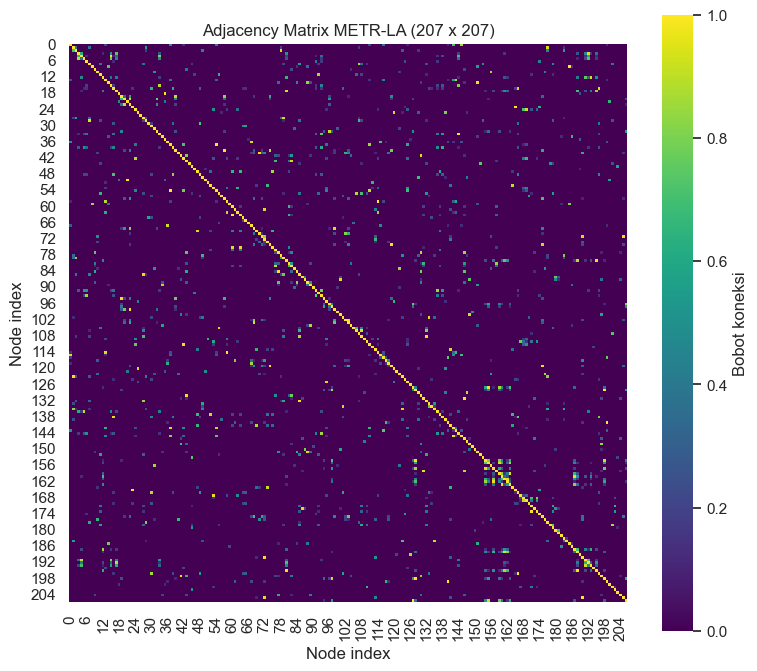

In [64]:
plt.figure(figsize=(9, 8))
sns.heatmap(adj_mx, cmap="viridis", square=True, cbar_kws={"label": "Bobot koneksi"})
plt.title("Adjacency Matrix METR-LA (207 x 207)")
plt.xlabel("Node index"); plt.ylabel("Node index")
plt.show()

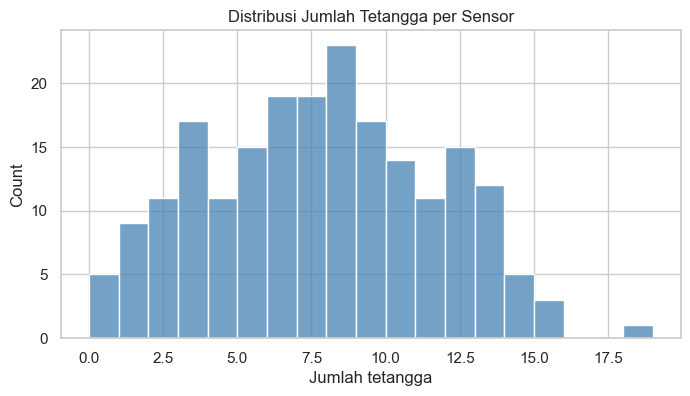

Sensor tanpa tetangga sama sekali: 5


In [65]:
degree = (adj_mx > 0).sum(axis=1) - 1   
plt.figure(figsize=(8, 4))
sns.histplot(degree, bins=range(0, degree.max() + 2), color="steelblue")
plt.title("Distribusi Jumlah Tetangga per Sensor")
plt.xlabel("Jumlah tetangga"); plt.show()
print("Sensor tanpa tetangga sama sekali:", int((degree == 0).sum()))

# Time series kecepatan (`METR-LA.h5`)

In [66]:
def load_metrla_h5(path):
    try:
        return pd.read_hdf(path)
    except Exception as e:
        print(f"[INFO] pd.read_hdf gagal ({type(e).__name__}), fallback ke PyTables...")
        import tables
        with tables.open_file(str(path), mode="r") as f:
            axis0 = f.root.df.axis0[:]
            axis1 = f.root.df.axis1[:]
            values = f.root.df.block0_values[:]
        cols = [c.decode() if isinstance(c, bytes) else c for c in axis0]
        return pd.DataFrame(values, index=pd.to_datetime(axis1), columns=cols)

speed_df = load_metrla_h5(SPEED_H5_PATH)
print("Shape:", speed_df.shape, "(timestamp x sensor)")
print("Rentang:", speed_df.index.min(), "->", speed_df.index.max())
print("Interval:", pd.infer_freq(speed_df.index[:20]))
speed_df.iloc[:10, :6]

Shape: (34272, 207) (timestamp x sensor)
Rentang: 2012-03-01 00:00:00 -> 2012-06-27 23:55:00
Interval: 5min


,773869,767541,767542,717447,717446,717445
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-03-01 00:25:00,57.333333,69.000000,67.666667,61.666667,67.333333,69.000000
2012-03-01 00:30:00,66.500000,63.875000,67.875000,62.375000,64.375000,67.750000
2012-03-01 00:35:00,63.625000,67.250000,63.250000,60.500000,57.375000,65.500000
2012-03-01 00:40:00,68.750000,65.250000,63.500000,63.000000,65.125000,68.000000
2012-03-01 00:45:00,63.500000,61.500000,62.500000,58.125000,66.625000,64.250000


In [78]:
if list(speed_df.columns) != list(sensor_ids):
    print("Urutan beda -> reindex")
    speed_df = speed_df.reindex(columns=sensor_ids)
else:
    print("Urutan kolom time series sama persis dengan urutan node adjacency")
assert list(speed_df.columns) == list(sensor_ids)

Urutan kolom time series sama persis dengan urutan node adjacency


In [68]:
speed_df.describe().T.head(10) 

,count,mean,std,min,25%,50%,75%,max
773869,34272.0,54.631359,22.619199,0.0,60.364583,64.888889,66.875000,70.0
767541,34272.0,60.452789,15.970239,0.0,63.000000,65.000000,66.375000,70.0
767542,34272.0,60.726120,18.313353,0.0,65.444444,67.375000,68.444444,70.0
717447,34272.0,49.524287,15.843261,0.0,50.333333,53.875000,58.125000,70.0
717446,34272.0,46.079798,19.350345,0.0,34.666667,46.000000,64.500000,70.0
717445,34272.0,50.952003,16.681760,0.0,49.555556,56.111111,60.333333,70.0
773062,34272.0,54.471684,17.984761,0.0,55.750000,62.111111,65.000000,70.0
767620,34272.0,57.255095,18.751065,0.0,61.000000,63.333333,65.000000,70.0
737529,34272.0,56.068044,18.240361,0.0,58.222222,62.444444,64.888889,70.0
717816,34272.0,52.871841,23.343805,0.0,43.428571,65.875000,67.625000,70.0


# Missing values

Proporsi data hilang: 8.11%
Sensor yang 100% hilang: 0

Top 10 sensor dengan missing terbanyak (%):
718076    20.10
716939    18.86
760987    16.14
716955    15.68
769418    15.61
769405    15.60
717481    15.06
717510    15.04
717513    14.06
717576    13.64
dtype: float64


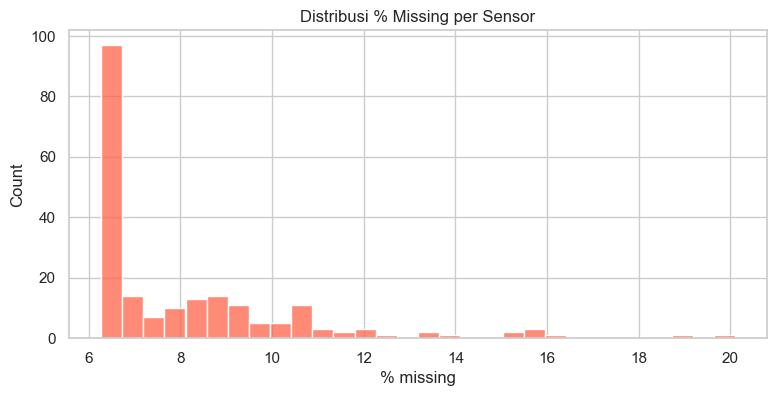

In [69]:
raw_values = speed_df.values.astype(np.float32)
missing_mask = (raw_values == 0.0)    

print(f"Proporsi data hilang: {missing_mask.mean() * 100:.2f}%")
print("Sensor yang 100% hilang:", int(missing_mask.all(axis=0).sum()))

miss_per_sensor = pd.Series(missing_mask.mean(axis=0) * 100, index=sensor_ids).sort_values(ascending=False)
print("\nTop 10 sensor dengan missing terbanyak (%):")
print(miss_per_sensor.head(10).round(2))

plt.figure(figsize=(9, 4))
sns.histplot(miss_per_sensor, bins=30, color="tomato")
plt.title("Distribusi % Missing per Sensor"); plt.xlabel("% missing"); plt.show()

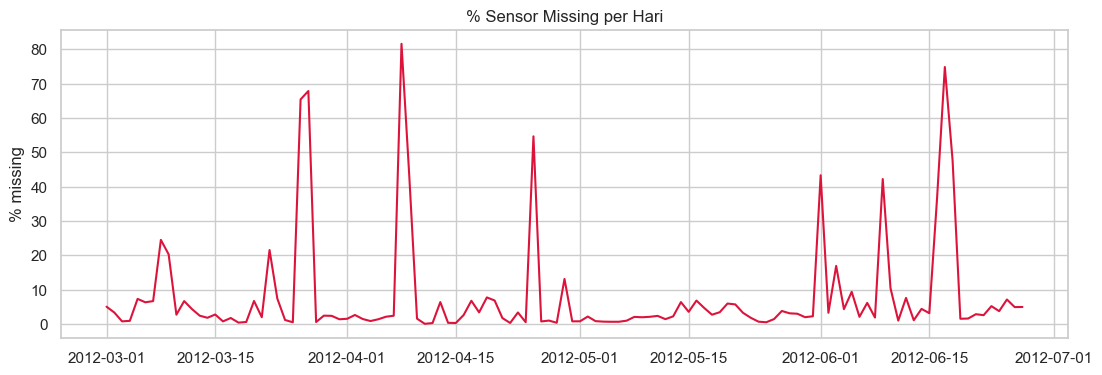

In [70]:
missing_by_day = (
    pd.Series(missing_mask.mean(axis=1) * 100, index=speed_df.index)
    .groupby(speed_df.index.normalize())  
    .mean()
)

plt.figure(figsize=(13, 4))
plt.plot(missing_by_day.index, missing_by_day.values, color="crimson")
plt.title("% Sensor Missing per Hari"); plt.ylabel("% missing"); plt.show()

**Imputasi**: untuk input model, nilai missing diisi forward-fill lalu backward-fill per sensor. Tapi `missing_mask` asli disimpan, supaya titik hasil imputasi **nggak ikut dihitung** di loss & evaluasi.

In [71]:
speed_imputed = speed_df.replace(0.0, np.nan).ffill().bfill()
left = int(speed_imputed.isnull().sum().sum())
if left > 0:
    print(f"Masih ada {left} NaN (sensor kosong total), isi median global")
    speed_imputed = speed_imputed.fillna(speed_imputed.stack().median())
print("NaN tersisa:", int(speed_imputed.isnull().sum().sum()))

NaN tersisa: 0


# Pola kecepatan

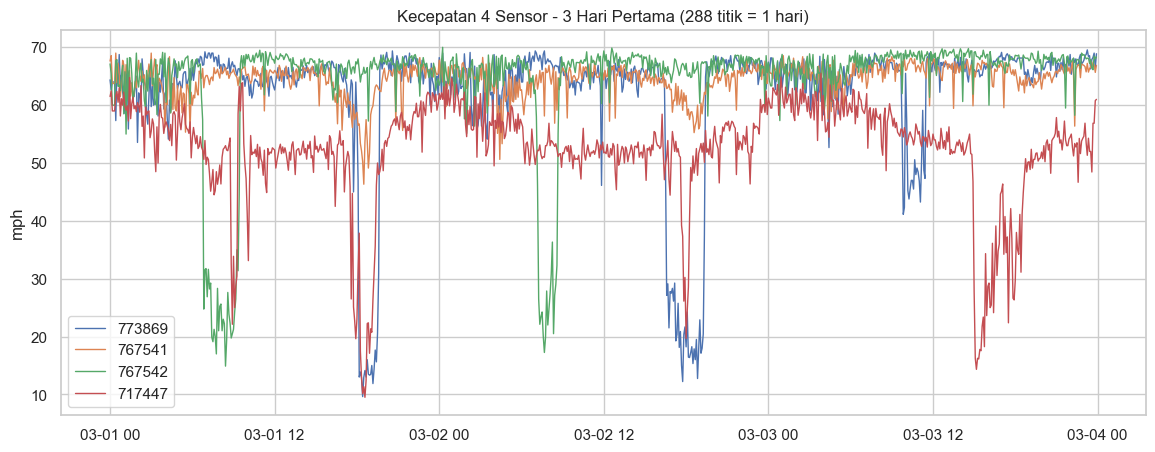

In [72]:
plt.figure(figsize=(14, 5))
for sid in sensor_ids[:4]:
    plt.plot(speed_imputed.index[:288 * 3], speed_imputed[sid].iloc[:288 * 3], label=sid, linewidth=1)
plt.title("Kecepatan 4 Sensor - 3 Hari Pertama (288 titik = 1 hari)")
plt.ylabel("mph"); plt.legend(); plt.show()

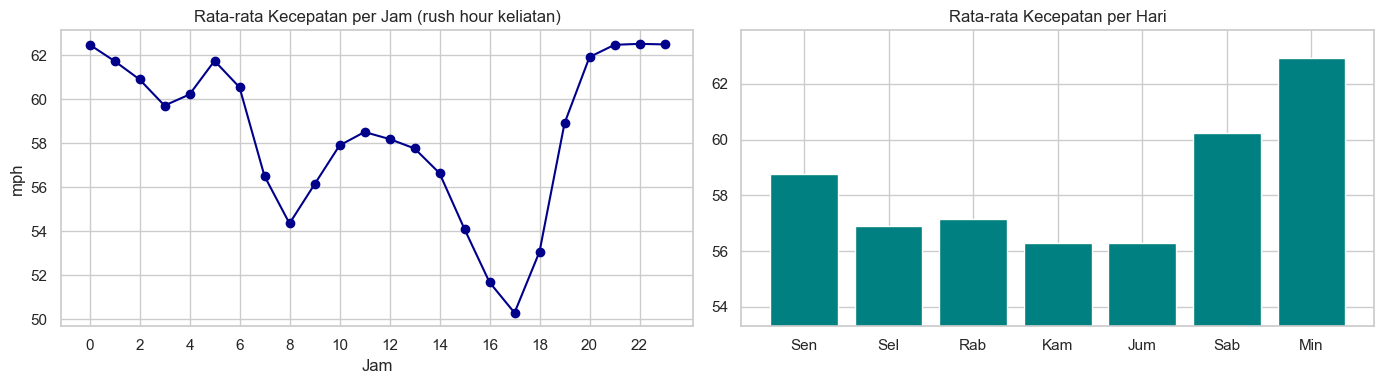

In [73]:
hour = speed_imputed.index.hour
dow = speed_imputed.index.dayofweek
systemwide = speed_imputed.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
systemwide.groupby(hour).mean().plot(marker="o", ax=axes[0], color="darkblue")
axes[0].set_title("Rata-rata Kecepatan per Jam (rush hour keliatan)")
axes[0].set_xlabel("Jam"); axes[0].set_ylabel("mph"); axes[0].set_xticks(range(0, 24, 2))

labels = ["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"]
means = systemwide.groupby(dow).mean()
axes[1].bar([labels[i] for i in means.index], means.values, color="teal")
axes[1].set_title("Rata-rata Kecepatan per Hari"); axes[1].set_ylim(means.min() - 3, means.max() + 1)
plt.tight_layout(); plt.show()

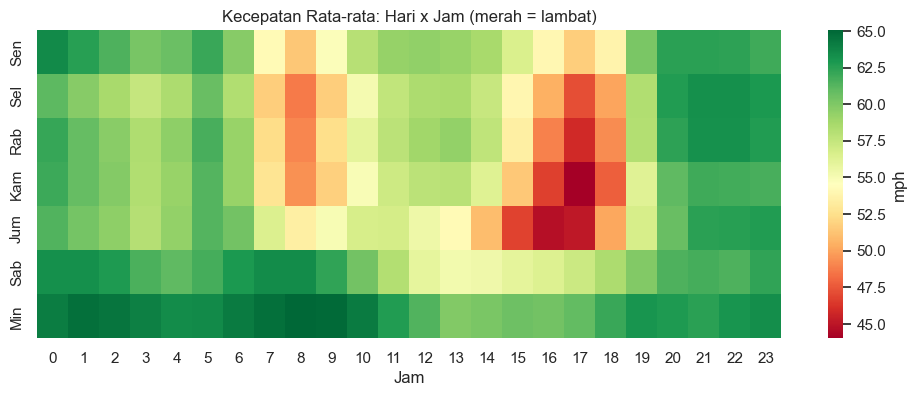

In [74]:
pivot_hd = systemwide.groupby([dow, hour]).mean().unstack()
pivot_hd.index = labels
plt.figure(figsize=(12, 4))
sns.heatmap(pivot_hd, cmap="RdYlGn", cbar_kws={"label": "mph"})
plt.title("Kecepatan Rata-rata: Hari x Jam (merah = lambat)")
plt.xlabel("Jam"); plt.show()

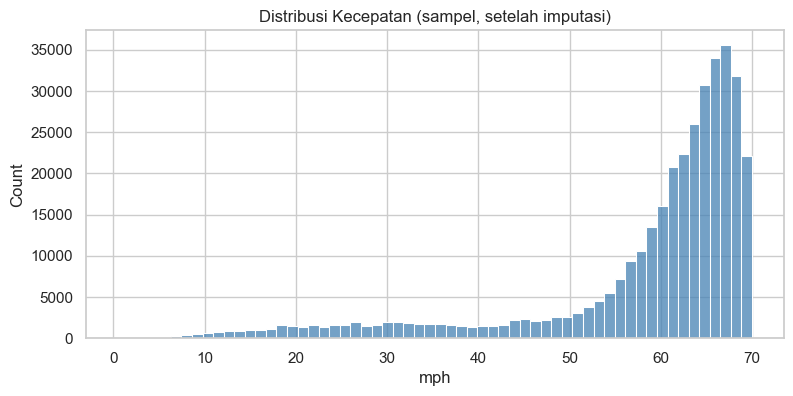

In [75]:
plt.figure(figsize=(9, 4))
sns.histplot(speed_imputed.values.flatten()[::20], bins=60, color="steelblue")
plt.title("Distribusi Kecepatan (sampel, setelah imputasi)"); plt.xlabel("mph"); plt.show()

# Validasi graph
Membandingin korelasi kecepatan antar sensor yang **terhubung** vs **tidak terhubung**. Jika graph-nya beneran mencerminkan hubungan fisik, yang terhubung harusnya lebih berkorelasi.

Korelasi rata-rata, sensor TERHUBUNG      : 0.418  (n=776)
Korelasi rata-rata, sensor TIDAK terhubung: 0.192  (n=20545)


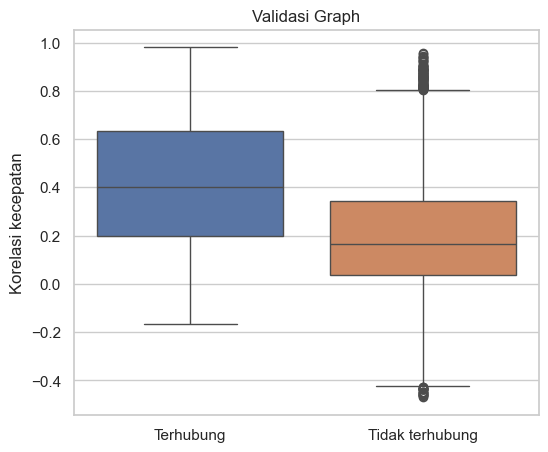

In [76]:
corr = speed_imputed.corr().values
iu = np.triu_indices(num_nodes, k=1)
connected = adj_mx[iu] > 0
cv = corr[iu]

print(f"Korelasi rata-rata, sensor TERHUBUNG      : {cv[connected].mean():.3f}  (n={connected.sum()})")
print(f"Korelasi rata-rata, sensor TIDAK terhubung: {cv[~connected].mean():.3f}  (n={(~connected).sum()})")

plt.figure(figsize=(6, 5))
sns.boxplot(data=[cv[connected], cv[~connected]])
plt.xticks([0, 1], ["Terhubung", "Tidak terhubung"])
plt.ylabel("Korelasi kecepatan"); plt.title("Validasi Graph")
plt.show()

In [77]:
np.save(PROCESSED_DIR / "adj_matrix.npy", adj_mx)
np.save(PROCESSED_DIR / "speed_values_imputed.npy", speed_imputed.values.astype(np.float32))
np.save(PROCESSED_DIR / "missing_mask.npy", missing_mask)
speed_imputed.index.to_series().reset_index(drop=True).to_csv(PROCESSED_DIR / "timestamps.csv", index=False, header=["timestamp"])
with open(PROCESSED_DIR / "sensor_order.txt", "w") as f:
    f.write("\n".join(sensor_ids))